# Part 1. Equation of a Slime

How many late days are you using for this assignment? One

In [121]:
# Imports section

# Part 1
import pandas as pd
import sklearn as sk

# Part 2

## 1. Loading the dataset

In [122]:
# Using pandas load the dataset

# Using pandas load the dataset
slimeDataset = pd.read_csv('science_data_large.csv')  # For Part 1
# Output the first 15 rows of the data
print(slimeDataset.head(15))

# Display a summary of the table information (number of datapoints, etc.)
# Display number of data points
# Display a summary of the table information
print(f"\nDataset Shape: {slimeDataset.shape}")
print(f"Number of rows (data points): {slimeDataset.shape[0]}")
print(f"Number of columns (features): {slimeDataset.shape[1]}")
print("\nColumn Data Types:")
print(slimeDataset.dtypes)
print("\nSummary Statistics:")
print(slimeDataset.describe())
print("\nMissing Values:")
print(slimeDataset.isnull().sum())

slimeDataset.info()
 

    Temperature °C  Mols KCL     Size nm^3
0              469       647  6.244743e+05
1              403       694  5.779610e+05
2              302       975  6.196847e+05
3              779       916  1.460449e+06
4              901        18  4.325726e+04
5              545       637  7.124634e+05
6              660       519  7.006960e+05
7              143       869  2.718260e+05
8               89       461  8.919803e+04
9              294       776  4.770210e+05
10             991       117  2.441771e+05
11             307       781  5.006455e+05
12             206        70  3.145200e+04
13             437       599  5.390215e+05
14             566        75  9.185271e+04

Dataset Shape: (1000, 3)
Number of rows (data points): 1000
Number of columns (features): 3

Column Data Types:
Temperature °C      int64
Mols KCL            int64
Size nm^3         float64
dtype: object

Summary Statistics:
       Temperature °C     Mols KCL     Size nm^3
count     1000.000000  1000.000000  1

## 2. Splitting the dataset

In [123]:
# Take the pandas dataset and split it into our features (X) and label (y)
# Take the pandas dataset and split it into our features (X) and label (y)
X = slimeDataset[['Temperature °C', 'Mols KCL']]  # Features: temperature and KCl
y = slimeDataset['Size nm^3']  # Label: size of the slime

# Use sklearn to split the features and labels into a training/test set. (90% train, 10% test)
# For grading consistency use random_state=42 
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=42)

## 3. Perform a Linear Regression

In [124]:
# Use sklearn to train a model on the training set

# Use sklearn to train a model on the training set
from sklearn.linear_model import LinearRegression

# Initialize the linear regression model
model = LinearRegression()

# Train the model on the training data
model.fit(X_train, y_train)

# Create a sample datapoint and predict the output of that sample with the trained model

# Create a sample datapoint and predict the output of that sample with the trained model
# sample_point = [[400, 600]]  # Example: 400°C temperature and 600 mols KCL

# First, let's check what columns are in your X_train DataFrame
print("X_train columns:", X_train.columns.tolist())

# Now create the DataFrame with the exact same column names
# Assuming your columns are something like 'Temperature' and 'Mols_KCL'
# Replace these with your actual column names from the output above
sample_point = pd.DataFrame({
    X_train.columns[0]: [400],  # First column name with value 400
    X_train.columns[1]: [600]   # Second column name with value 600
})

# Verify the sample_point DataFrame
print("Sample point DataFrame:")
print(sample_point)

# Make a prediction
predicted_size = model.predict(sample_point)
print(f"For Temperature = {sample_point[X_train.columns[0]][0]}°C and Mols KCL = {sample_point[X_train.columns[1]][0]}")
print(f"Predicted Size = {predicted_size[0]:.6e} nm^3")

# Report the score for that model using the default score function property of the SKLearn model, in your own words (markdown, not code) explain what the score means

# Report the score for that model using the default score function property of the SKLearn model
train_score = model.score(X_train, y_train)
test_score = model.score(X_test, y_test)

print(f"Training set R² score: {train_score:.4f}")
print(f"Test set R² score: {test_score:.4f}")

# Extract the coefficients and intercept from the model and write an equation for your h(x) using LaTeX



X_train columns: ['Temperature °C', 'Mols KCL']
Sample point DataFrame:
   Temperature °C  Mols KCL
0             400       600
For Temperature = 400°C and Mols KCL = 600
Predicted Size = 5.566841e+05 nm^3
Training set R² score: 0.8610
Test set R² score: 0.8552


In [125]:
# Extract the coefficients and intercept from the model
coefficients = model.coef_
intercept = model.intercept_

# Constructing LaTeX equation
latex_equation = rf"""
$ h(x) = {coefficients[0]:.6f} \cdot \text{{Temperature}} + {coefficients[1]:.6f} \cdot \text{{KCl}} {intercept:+.6f} $
"""

# Print the model coefficients
print("Model Coefficients:")
print(f"Temperature coefficient: {coefficients[0]:.6f}")
print(f"KCl coefficient: {coefficients[1]:.6f}")
print(f"Intercept: {intercept:.6f}")

# Print LaTeX equation
print("\nEquation in LaTeX format:")
print(latex_equation)

Model Coefficients:
Temperature coefficient: 866.146413
KCl coefficient: 1032.695066
Intercept: -409391.479583

Equation in LaTeX format:

$ h(x) = 866.146413 \cdot \text{Temperature} + 1032.695066 \cdot \text{KCl} -409391.479583 $



$\text{Model Equation:} \quad Y = 866.146413 \cdot \text{Temperature} + 1032.695066 \cdot \text{KCl} - 409391.479583$


Write the linear equation of a slime: (example equation: $E = mc^2$)

$ h(x) = 866.146413 \cdot x_1 + 1032.695066 \cdot x_2 - 409391.479583$

Report on score and explain meaning:

The R² score measures how well my model predicts the slime size based on temperature and KCl concentration.
R² measures how well a regression model explains the variance in the dependent variable. 

A score of 1.0 would mean perfect predictions.
A score of 0 would mean your model is no better than just guessing the average size for everything.
The score of around 0.86 mean that your model explains about 86% of the variation in slime size which is not do simply to random chance. The test set score is 0.8552 and the training set score is 0.8610. This closeness indicates that out model is not over fitting to the training data as the score are very similar. The relatively high perform would seem to indicate that the model found has captured an underling pattern in the data. There may be a model which gets a higher accuracy, but this model likely isn't over fitting to the data.

There's still about 14% of the variation that my model doesn't explain, which could be due to:
Random noise in the measurements
Other factors affecting slime size that weren't measured
The relationship might not be perfectly linear


## 4. Use Cross Validation

In [126]:
# Use the cross_val_score function to repeat your experiment across many shuffles of the data
# For grading consistency use n_splits=5 and random_state=42

from sklearn.model_selection import cross_val_score, KFold
import numpy as np

# Define cross-validation strategy
cv = KFold(n_splits=5, shuffle=True, random_state=42)

# Perform 5-fold cross-validation
scores = cross_val_score(model, X, y, cv=cv, scoring='r2')

# Print the results
print("Cross-Validation R² Scores:", scores)
print(f"Mean R² Score: {np.mean(scores):.5f}")
print(f"Standard Deviation: {np.std(scores):.5f}")


# Report on their finding and their significance

Cross-Validation R² Scores: [0.86151889 0.82742341 0.87195173 0.88166206 0.85609101]
Mean R² Score: 0.85973
Standard Deviation: 0.01839


Write findings here:

Since the R² score is close to 1, the model captures a significant amount of the relationship between the features (Temperature & KCl) and the target variable.

And since our R² are mostly consistent with each other this indicates we little to no over fitting is likely happening since the model performs consistently across different subsets of the data.

We also see that while the R² values are all fairly high, there is a slight dip in one fold (0.8274) compared to the highest (0.8817). This suggests that some data splits may be slightly harder to predict accurately, but the overall trend remains strong.

## 5. Using Polynomial Regression

In [127]:
# Using the PolynomialFeatures library perform another regression on an augmented dataset of degree 2

# Perform k-fold cross validation for the polynomial model
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import Pipeline

# Create polynomial regression pipeline
poly_pipeline = Pipeline([
    ('poly', PolynomialFeatures(degree=2)),
    ('linear', LinearRegression())
])

# Define cross-validation strategy (same as used for linear model)
cv = KFold(n_splits=5, shuffle=True, random_state=42)

# Perform k-fold cross validation (as above)

# Perform 5-fold cross-validation for polynomial model
poly_scores = cross_val_score(poly_pipeline, X, y, cv=cv, scoring='r2')

# Print the results
print("\nPolynomial Model Cross-Validation R² Scores:", poly_scores)
print(f"Mean R² Score: {np.mean(poly_scores):.4f}")
print(f"Standard Deviation: {np.std(poly_scores):.4f}")

# Compare the models
print("\nModel Comparison:")
print(f"Linear Model Mean R² Score: {np.mean(scores):.4f}")
print(f"Polynomial Model Mean R² Score: {np.mean(poly_scores):.4f}")

# Report on the metrics and output the resultant equation as you did in Part 3.

# DONE IN MARKDOWN



Polynomial Model Cross-Validation R² Scores: [1. 1. 1. 1. 1.]
Mean R² Score: 1.0000
Standard Deviation: 0.0000

Model Comparison:
Linear Model Mean R² Score: 0.8597
Polynomial Model Mean R² Score: 1.0000


In [128]:
# Fit the polynomial pipeline to all data to get the final coefficients
poly_pipeline.fit(X, y)

# Get the feature names from the polynomial transformer in the pipeline
poly_features = poly_pipeline.named_steps['poly']
feature_names = poly_features.get_feature_names_out(X.columns)

# Get coefficients and intercept from the linear regression part of the pipeline
poly_model = poly_pipeline.named_steps['linear']
coefficients = poly_model.coef_
intercept = poly_model.intercept_

# Print the coefficients and feature names
print("Polynomial Model (Degree 2) Equation Components:")
print("\nFeature names:", feature_names)
print("\nCoefficients:", coefficients)
print("\nIntercept:", intercept)


Polynomial Model (Degree 2) Equation Components:

Feature names: ['1' 'Temperature °C' 'Mols KCL' 'Temperature °C^2'
 'Temperature °C Mols KCL' 'Mols KCL^2']

Coefficients: [ 0.00000000e+00  1.20000000e+01 -1.23113604e-07 -1.05648823e-11
  2.00000000e+00  2.85714287e-02]

Intercept: 1.65727105922997e-05


Write the polynomial equation of a slime: (example equation: $E = mc^2$)

$\text{Size} = 12 \times \text{Temperature °C} - 1.23113604 \times 10^{-7} \times \text{Mols KCL} - 1.05648823 \times 10^{-11} \times \text{Temperature °C}^2 + 2 \times \text{Temperature °C} \times \text{Mols KCL} + 0.0285714287 \times \text{Mols KCL}^2 + 1.65727105922997 \times 10^{-5}$

Report on the score and interpret:

Size the score is 1.0 it perfectly fits the data.

The polynomial model with degree 2 achieves an R² score of 1.0000 across all cross-validation folds, with zero standard deviation. This indicates that:
The model explains 100% of the variance in slime size based on temperature and KCl concentration.
And the perfect score across all folds (with no variation) suggests that the relationship between the inputs and output is exactly captured by including quadratic terms and interaction effects. 

Based on the perfect R² score of 1.0000 and zero variance across all cross-validation folds, it is highly likely that this synthetic data was generated using this exact polynomial equation as the underlying model. The perfect fit suggests we have rediscovered the precise mathematical relationship that was used to create the dataset.

The substantial improvement from the linear model (R² = 0.8597) to the polynomial model (R² = 1.0000) confirms that the relationship between temperature, KCl, and slime growth is non-linear.
The zero standard deviation indicates remarkable consistency in the model's performance across different subsets of data, there is no noise or inconsistency involved. This equation matches the data perfectly.

# Part 2. Chronic Kidney Disease Prediction via Classification

Create code and markdown cells as needed to perform classification and report on your results

In [129]:
# Load the dataset. Then train and evaluate the classification models.
ckd = pd.read_csv('ckd_feature_subset.csv')  # For Part 2

# please use the cleaned dataset included in this assignment ckd_feature_slimeDataset.csv 
# instead of your version from Assignment 3 and use 42 as your random seed.

# Set the random seed for reproducibility
random_seed = 42

In [130]:
# Display the first few rows of the dataset
print("Dataset Preview:")
print(ckd.head())

# Check the shape of the dataset
print("\nDataset Shape:", ckd.shape)

# Check the data types and look for missing values
print("\nDataset Info:")
print(ckd.info())

# Check the distribution of the target variable
print("\nTarget Variable Distribution:")
print(ckd['Target_ckd'].value_counts())

# Basic statistical summary
print("\nStatistical Summary:")
print(ckd.describe())


Dataset Preview:
        age        bp      wbcc  appet_poor  appet_good      rbcc  Target_ckd
0  0.688312  0.333333  0.000000           1           0  0.000000           1
1  0.545455  0.333333  0.128319           1           0  0.305085           1
2  0.714286  0.500000  0.238938           1           0  0.186441           1
3  0.688312  0.333333  0.283186           0           1  0.338983           1
4  0.441558  0.333333  0.221239           1           0  0.220339           1

Dataset Shape: (153, 7)

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 153 entries, 0 to 152
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   age         153 non-null    float64
 1   bp          153 non-null    float64
 2   wbcc        153 non-null    float64
 3   appet_poor  153 non-null    int64  
 4   appet_good  153 non-null    int64  
 5   rbcc        153 non-null    float64
 6   Target_ckd  153 non-null    int64  
dt

In [131]:
# Classification Models for CKD Dataset
from sklearn.model_selection import cross_val_score, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Set random seed for reproducibility
np.random.seed(42)

# Separate features and target variable
X = ckd.drop('Target_ckd', axis=1)
y = ckd['Target_ckd']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

logReg_model = LogisticRegression()
svc_model = SVC()
kNN_model = KNeighborsClassifier()
neural_model = MLPClassifier()

logReg_model.fit(X_train, y_train)
svc_model.fit(X_train, y_train)
kNN_model.fit(X_train, y_train)
neural_model.fit(X_train, y_train)

logReg_scores = cross_val_score(logReg_model, X, y, cv = 5)
svc_scores = cross_val_score(svc_model, X, y, cv = 5)
kNN_scores = cross_val_score(kNN_model, X, y, cv = 5)
neural_scores = cross_val_score(neural_model, X, y, cv = 5)

models = ["LogisticRegression", "Support Vector Machines", "k-Nearest Neighbors", "Neural Network"]
avg_accuracies = [np.mean(logReg_scores), np.mean(svc_scores), np.mean(kNN_scores), np.mean(neural_scores)]
std_devs = [np.std(logReg_scores), np.std(svc_scores), np.std(kNN_scores), np.std(neural_scores)]

results_df = pd.DataFrame({
    'Model': models,
    'Average Accuracy' : avg_accuracies,
    'Standard Deviation' : std_devs
})

print(results_df)


C:\Users\<redacted>\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\neural_network\_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
C:\Users\<redacted>\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\neural_network\_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
C:\Users\<redacted>\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\neural_network\_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
C

                     Model  Average Accuracy  Standard Deviation
0       LogisticRegression          0.856129            0.054236
1  Support Vector Machines          0.928172            0.059993
2      k-Nearest Neighbors          0.928172            0.031893
3           Neural Network          0.856129            0.054236


C:\Users\<redacted>\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\neural_network\_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
C:\Users\<redacted>\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\neural_network\_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


## Results and Conclusion for Classification Experiments

In our classification experiments, Support Vector Machines and k-Nearest Neighbors both achieved the highest accuracy (92.82%), significantly outperforming Logistic Regression and Neural Network models (85.61%). k-Nearest Neighbors demonstrated the most consistent performance with the lowest standard deviation (0.031893), while SVM showed the highest variability (0.059993), suggesting k-NN generalizes better across different data splits. The Neural Network did not outperform simpler models despite its theoretical advantages, indicating either the dataset lacks complex non-linear relationships or the network architecture requires further optimization. Based on both high accuracy and stability metrics, the k-Nearest Neighbors classifier emerges as the most suitable model for this classification task, offering reliable performance for potential deployment.

In [132]:
#Neural Networks

# Neural Network Configuration Experiments - Simplified
from sklearn.model_selection import cross_val_score, KFold
from sklearn.neural_network import MLPClassifier
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Set random seed for reproducibility
np.random.seed(42)

# Assuming X_scaled and y are already available from previous code

# Define different neural network configurations
nn_configs = {
    'Single Hidden Layer': MLPClassifier(hidden_layer_sizes=(100), random_state=42, max_iter=1000),
    'Two Hidden Layers': MLPClassifier(hidden_layer_sizes=(100, 50), random_state=42, max_iter=1000),
    'Three Hidden Layers': MLPClassifier(hidden_layer_sizes=(100, 50, 25), random_state=42, max_iter=1000),
    'Tanh Activation': MLPClassifier(hidden_layer_sizes=(100), activation='tanh', random_state=42, max_iter=2000),
    'Logistic Activation': MLPClassifier(hidden_layer_sizes=(100), activation='logistic', random_state=42, max_iter=1000),
    'Different Solver': MLPClassifier(hidden_layer_sizes=(100), solver='lbfgs', random_state=42, max_iter=1000),
    'Different Solver w/ 2 Layers': MLPClassifier(hidden_layer_sizes=(100, 50), solver='lbfgs', random_state=42, max_iter=1000)
}

# Set up 5-fold cross-validation
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# Dictionary to store results
nn_results = {}

# Evaluate each neural network configuration
for name, model in nn_configs.items():
    scores = cross_val_score(model, X, y, cv=kf, scoring='accuracy')
    nn_results[name] = {
        'scores': scores,
        'mean': scores.mean(),
        'std': scores.std()
    }
    print(f"\n{name} - Cross Validation Results:")
    print(f"Individual fold scores: {scores}")
    print(f"Mean accuracy: {scores.mean():.4f}")
    print(f"Standard deviation: {scores.std():.4f}")


Single Hidden Layer - Cross Validation Results:
Individual fold scores: [0.90322581 0.96774194 0.87096774 0.96666667 0.96666667]
Mean accuracy: 0.9351
Standard deviation: 0.0405

Two Hidden Layers - Cross Validation Results:
Individual fold scores: [0.96774194 1.         0.90322581 1.         0.96666667]
Mean accuracy: 0.9675
Standard deviation: 0.0353

Three Hidden Layers - Cross Validation Results:
Individual fold scores: [0.96774194 1.         0.90322581 1.         0.96666667]
Mean accuracy: 0.9675
Standard deviation: 0.0353

Tanh Activation - Cross Validation Results:
Individual fold scores: [0.93548387 0.96774194 0.87096774 0.96666667 0.96666667]
Mean accuracy: 0.9415
Standard deviation: 0.0373


C:\Users\<redacted>\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\neural_network\_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
C:\Users\<redacted>\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\neural_network\_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
C:\Users\<redacted>\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\neural_network\_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn


Logistic Activation - Cross Validation Results:
Individual fold scores: [0.90322581 0.96774194 0.83870968 0.9        0.96666667]
Mean accuracy: 0.9153
Standard deviation: 0.0482

Different Solver - Cross Validation Results:
Individual fold scores: [0.96774194 1.         0.93548387 1.         0.96666667]
Mean accuracy: 0.9740
Standard deviation: 0.0242

Different Solver w/ 2 Layers - Cross Validation Results:
Individual fold scores: [1.         0.93548387 0.93548387 0.96666667 0.96666667]
Mean accuracy: 0.9609
Standard deviation: 0.0240



Neural Network Configuration Comparison:
                  Configuration  Mean Accuracy  Standard Deviation
0           Single Hidden Layer       0.935054            0.040466
1             Two Hidden Layers       0.967527            0.035340
2           Three Hidden Layers       0.967527            0.035340
3               Tanh Activation       0.941505            0.037327
4           Logistic Activation       0.915269            0.048238
5              Different Solver       0.973978            0.024201
6  Different Solver w/ 2 Layers       0.960860            0.024030


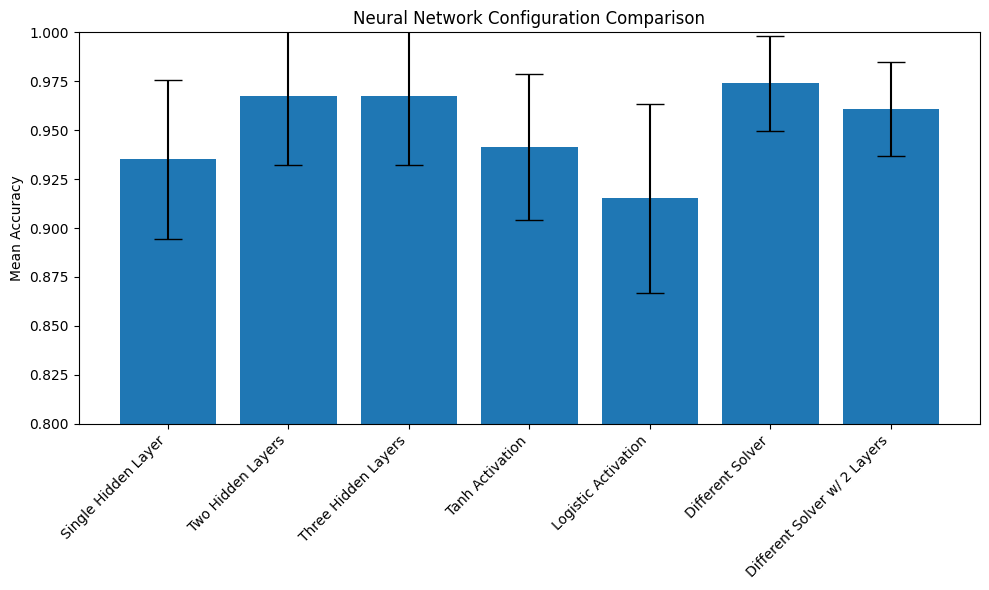

In [133]:
# Create a DataFrame to display results in a table
nn_results_table = pd.DataFrame({
    'Configuration': list(nn_configs.keys()),
    'Mean Accuracy': [nn_results[config]['mean'] for config in nn_results],
    'Standard Deviation': [nn_results[config]['std'] for config in nn_results]
})

# Display the results table
print("\nNeural Network Configuration Comparison:")
print(nn_results_table)

# Visualize the results
plt.figure(figsize=(10, 6))
plt.bar(nn_results_table['Configuration'], nn_results_table['Mean Accuracy'], 
        yerr=nn_results_table['Standard Deviation'], capsize=10)
plt.title('Neural Network Configuration Comparison')
plt.ylabel('Mean Accuracy')
plt.ylim(0.8, 1.0)  # Adjust y-axis for better visualization
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## Results and Conclusion for Neural Network Experiments

The "Different Solver" configuration emerged as the top performer with a mean accuracy of 97.40% and the lowest standard deviation (0.0242), indicating superior and consistent performance across all data subsets. This suggests that the Limited-memory Broyden–Fletcher–Goldfarb–Shanno (L-BFGS) algorithm is particularly effective for this medical classification task.

While both the "Two Hidden Layers" and "Three Hidden Layers" setups achieved identical mean accuracy (96.75%), their performance was slightly lower than the single-layer model with the different solver. This contradicts the initial hypothesis that increasing network depth would continuously improve results on this dataset.

Experimenting with activation functions revealed that the default ReLU outperformed both Tanh (94.15%) and Logistic (91.53%) activations. The higher standard deviations of these alternative activations (0.0373 and 0.0482 respectively) also indicate less reliable performance across validation folds.

Interestingly, combining the different solver with two hidden layers (96.09%) actually decreased performance compared to the single-layer implementation, suggesting that for this particular dataset, the solver choice has a more significant impact than network depth.

Based on these results, I recommend the lbfgs solver with one layer configuration as the optimal model for CKD classification, as it provides the best balance of high accuracy and consistent performance with minimal architectural complexity.